In [8]:
# This part of the code is used to load the data and perform some basic preprocessing, including mapping occupation to Kuppuswamy scores

import pandas as pd

# Here we are loading the data from an Excel file. The data is assumed to be in a sheet named "Combined" in the file "SES_Mastersheet.xlsx" located in the "../mock-data/" directory.
df = pd.read_excel(
    "../mock-data/SES_Mastersheet.xlsx",
    sheet_name="Combined"
)

# Since we don't need all the data, we are only keeping relevant columns 
df = df[["MRNO", "GENDER", "AGE", "Occupation", "Category"]].copy()

# 1. Occupation → Kuppuswamy; Converting occupation raw to kuppuswamy scores.
kupp_map = {
    "Politician": 10, "Manager": 10, "Central Government Service": 10,
    "State Government Service": 10, "Tahsildar": 10,
    "Doctor": 9, "Doctor-Dentist": 9, "Doctor-General Physician": 9,
    "Doctor-Ophthalmologist": 9, "Doctor-Homeopathist": 9,
    "Doctor-Pediatrician": 9, "Doctor-Gynecologist": 9,
    "Doctor-Surgeon": 9, "Doctor-Neurologist": 9,
    "Doctor-Siddha": 9, "Doctor-Ayurvedic": 9,
    "Advocate": 9, "Architecture": 9, "AUDITOR": 9,
    "Engineer": 9, "IT Professional": 9,
    "Professor / Teacher / Education": 9, "Doctorate": 9,
    "Reporter": 8, "Accounts/Finance": 8, "Bank": 8,
    "IT Employee": 8, "Supervisor": 8, "Armed Forces": 8, "Police": 8,
    "Clerk": 7, "Government": 7,
    "Business": 6, "Self Employed": 6, "Fashion / Saloon": 6,
    "Retired Employee": 6, "Father In Church": 6, "Priest": 6, "Social Service": 6,
    "Farmer / Agriculture": 5,
    "Private Sector": 4,
    "Driver": 3, "Courier": 3,
    "Daily wages": 2,
    "Housewife": 1, "Retired": 1, "Armed Forces-Retired": 1, "Student": 1,
}

df["Occupation"] = df["Occupation"].str.strip()
df["Occupation"] = df["Occupation"].replace({"NIL": None, "": None})
df["Kupp_Occupation"] = df["Occupation"].map(kupp_map)

# Here, I am dropping the rows where kupp_occupation is reported as NaN
n_before = len(df)
print(f"Rows before removing missing occupation: {n_before}")

df = df.dropna(subset=["Kupp_Occupation"])

n_after = len(df)
n_removed = n_before - n_after
print(f"Rows after removing missing occupation:  {n_after}")
print(f"Rows removed:                            {n_removed}")

# 2. Gender → numeric; here, I'm converting gender to numeric values for quantitative analysis. M is mapped to 1 and F is mapped to 2. Any other values will be mapped to NaN.
df["GENDER"] = df["GENDER"].str.strip()
df["New_Gender"] = df["GENDER"].map({"M": 1, "F": 2})

# 3. Age → grouped 
# Groupings based on: Sathish et al. (2010) Indian J Med Res PMC2878695
def age_group(age):
    if   age < 30:  return 0
    elif age <= 39: return 1
    elif age <= 49: return 2
    elif age <= 59: return 3
    else:           return 4

df["New_Age"] = df["AGE"].apply(age_group)

# 4. Category → numeric; here, I'm converting category to a numeric value for quant. analysis.
df["Category"] = df["Category"].str.strip()
df["Category_New"] = df["Category"].map({"Non_Diala": 0, "Active": 1, "Inactive": 2})

# Affirming the final data frame to be used in further analysis.
final_df = df[["MRNO", "GENDER", "AGE", "Occupation", "Category",
               "Kupp_Occupation", "New_Age", "New_Gender", "Category_New"]].copy()

# If you want to preview the data frame! This was really helpful for me when looking at a large dataset.
print(final_df.head(20))
print(f"\nShape: {final_df.shape}")

print(f"""
── Kupp_Occupation distribution ──────────────────────────────
  1  = Unemployed (Housewife, Retired, Student, Armed Forces-Retired)
  2  = Elementary occupation (Daily wages)
  3  = Plant/machine operators (Driver, Courier)
  4  = Craft/trade workers (Private Sector)
  5  = Skilled agricultural workers (Farmer/Agriculture)
  6  = Skilled/shop workers (Business, Self Employed, Priest etc.)
  7  = Clerks (Clerk, Government)
  8  = Technicians/associate professionals (Bank, IT Employee, Police etc.)
  9  = Professionals (Doctor, Engineer, Advocate etc.)
  10 = Legislators/senior officials (Politician, Manager, Central Govt etc.)
""")
print(final_df["Kupp_Occupation"].value_counts().sort_index())

print(f"""
── New_Age distribution ──────────────────────────────────────
  0 = Under 30
  1 = 30–39
  2 = 40–49
  3 = 50–59
  4 = 60 and above
""")
print(final_df["New_Age"].value_counts().sort_index())

print(f"""
── New_Gender distribution ───────────────────────────────────
  1 = Male (M)
  2 = Female (F)
""")
print(final_df["New_Gender"].value_counts().sort_index())

print(f"""
── Category_New distribution ─────────────────────────────────
  0 = Non_Diala (non-app user)
  1 = Active (DiaLA app user, >1 visit)
  2 = Inactive (DiaLA app user, 1 visit only)
""")
print(final_df["Category_New"].value_counts().sort_index())

Rows before removing missing occupation: 520
Rows after removing missing occupation:  520
Rows removed:                            0
               MRNO GENDER  AGE                       Occupation Category  \
0   MOCK-ACT-000000      F   69                         Engineer   Active   
1   MOCK-ACT-000001      M   80                     Architecture   Active   
2   MOCK-ACT-000002      F   48                     Architecture   Active   
3   MOCK-ACT-000003      F   45                        Housewife   Active   
4   MOCK-ACT-000004      M   69                           Police   Active   
5   MOCK-ACT-000005      F   29                             Bank   Active   
6   MOCK-ACT-000006      F   35             Armed Forces-Retired   Active   
7   MOCK-ACT-000007      F   61                            Clerk   Active   
8   MOCK-ACT-000008      M   66                        Housewife   Active   
9   MOCK-ACT-000009      M   26                          Student   Active   
10  MOCK-ACT-000010 

In [9]:
# Descriptive Statistics. I am running the descriptive statistics for the whole dataset here, across engagement categories.

print("=" * 60)
print("DESCRIPTIVE STATISTICS — SES_DATA_COMBINED")
print("=" * 60)

# Gender stuff!
print("\n── Gender ────────────────────────────────────────────────")
gender_counts = final_df["GENDER"].value_counts()
gender_pct    = final_df["GENDER"].value_counts(normalize=True) * 100
gender_summary = pd.DataFrame({"N": gender_counts, "%": gender_pct.round(1)})
gender_summary.index = gender_summary.index.map({"M": "Male", "F": "Female"})
print(gender_summary)

# Age (continuous) 
print("\n── Age (continuous) ──────────────────────────────────────")
print(final_df["AGE"].describe().round(1).to_string())

# Age (grouped); for wanting to see the stats for age groups.
print("\n── Age (grouped) ─────────────────────────────────────────")
age_labels = {0: "Under 30", 1: "30–39", 2: "40–49", 3: "50–59", 4: "60+"}
age_counts  = final_df["New_Age"].value_counts().sort_index()
age_pct     = final_df["New_Age"].value_counts(normalize=True).sort_index() * 100
age_summary = pd.DataFrame({"N": age_counts, "%": age_pct.round(1)})
age_summary.index = age_summary.index.map(age_labels)
print(age_summary)

# Occupation (continuous Kupp score)
print("\n── Kupp_Occupation (continuous) ──────────────────────────")
print(final_df["Kupp_Occupation"].describe().round(2).to_string())

# Occupation (by score) 
print("\n── Kupp_Occupation (by score) ────────────────────────────")
occ_labels = {
    1:  "1  — Unemployed (Housewife/Retired/Student)",
    2:  "2  — Daily wages",
    3:  "3  — Driver/Courier",
    4:  "4  — Private Sector",
    5:  "5  — Farmer/Agriculture",
    6:  "6  — Business/Self-Employed",
    7:  "7  — Clerk/Government",
    8:  "8  — Bank/IT Employee/Police",
    9:  "9  — Doctor/Engineer/Advocate",
    10: "10 — Politician/Manager/Senior Govt",
}
occ_counts  = final_df["Kupp_Occupation"].value_counts().sort_index()
occ_pct     = final_df["Kupp_Occupation"].value_counts(normalize=True).sort_index() * 100
occ_summary = pd.DataFrame({"N": occ_counts, "%": occ_pct.round(1)})
occ_summary.index = occ_summary.index.map(occ_labels)
print(occ_summary)

# Category - separating into the engagement categories.
print("\n── Category (DiaLA Group) ────────────────────────────────")
cat_labels  = {0: "Non-DiaLA", 1: "Active", 2: "Inactive"}
cat_counts  = final_df["Category_New"].value_counts().sort_index()
cat_pct     = final_df["Category_New"].value_counts(normalize=True).sort_index() * 100
cat_summary = pd.DataFrame({"N": cat_counts, "%": cat_pct.round(1)})
cat_summary.index = cat_summary.index.map(cat_labels)
print(cat_summary)

print("\n✔ Descriptive stats complete.")

DESCRIPTIVE STATISTICS — SES_DATA_COMBINED

── Gender ────────────────────────────────────────────────
          N     %
GENDER           
Male    279  53.7
Female  241  46.3

── Age (continuous) ──────────────────────────────────────
count    520.0
mean      54.3
std       21.2
min       18.0
25%       37.0
50%       54.0
75%       73.0
max       90.0

── Age (grouped) ─────────────────────────────────────────
            N     %
New_Age            
Under 30   84  16.2
30–39      66  12.7
40–49      73  14.0
50–59      79  15.2
60+       218  41.9

── Kupp_Occupation (continuous) ──────────────────────────
count    520.00
mean       6.94
std        2.84
min        1.00
25%        6.00
50%        8.00
75%        9.00
max       10.00

── Kupp_Occupation (by score) ────────────────────────────
                                               N     %
Kupp_Occupation                                       
1  — Unemployed (Housewife/Retired/Student)   52  10.0
2  — Daily wages                

STEP 4A: OCCUPATION SCORE BY ENGAGEMENT GROUP — DESCRIPTIVES

                          Non-DiaLA       Active     Inactive
------------------------------------------------------------
  N                             220          200          100
  Mean (SD)             6.93 (2.81)  6.71 (2.89)  7.41 (2.75)
  Median                        8.0          8.0          8.0
  IQR                       6.0–9.0      6.0–9.0      6.8–9.0
  Range                        1–10         1–10         1–10

INFERENTIAL STATISTICS

Kruskal-Wallis H = 5.344,  p = 0.0691

Post-hoc Pairwise Mann-Whitney U (Bonferroni corrected, n=3)
----------------------------------------------------------------------
  Non-DiaLA vs Active        U=22,924  p_raw=0.4501  p_bonf=1.0000  r=0.037  ns
  Non-DiaLA vs Inactive      U=9,684  p_raw=0.0802  p_bonf=0.2405  r=0.098  ns
  Active vs Inactive      U=8,412  p_raw=0.0228  p_bonf=0.0683  r=0.131  ns

  *** p<0.001  ** p<0.01  * p<0.05  ns = not significant


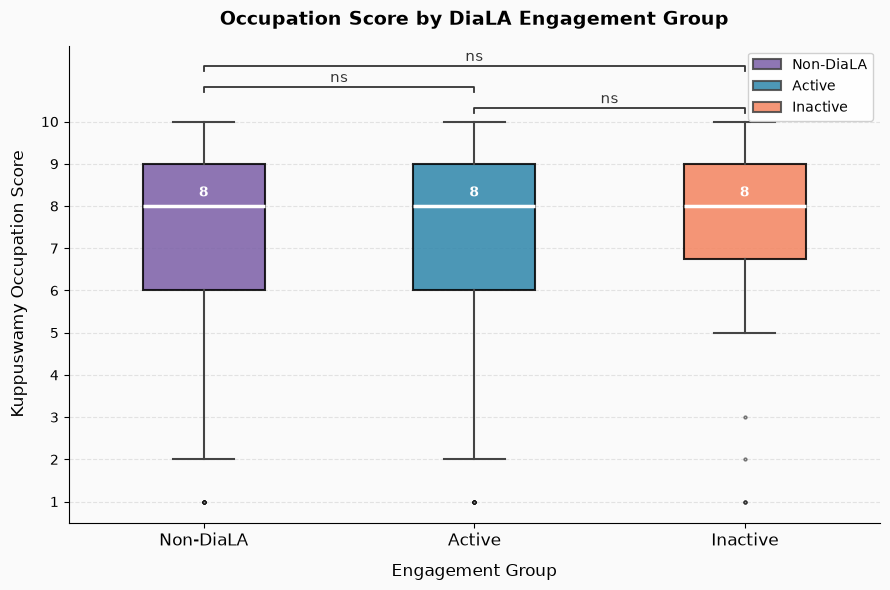


Box plot saved as step4a_boxplot.png


In [10]:
#  Occupation x Engagement Levels - Looking at how occupation scores vary across engagement levels. This includes descriptive statistics, Kruskal-Wallis test, post-hoc pairwise Mann-Whitney U tests, and a box plot visualization.

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
# Assumes final_df already exists 
 
group_labels = {0: "Non-DiaLA", 1: "Active", 2: "Inactive"}
colors       = ["#7B5EA7", "#2E86AB", "#F4845F"]   # purple, blue, orange
 
groups = {
    label: final_df.loc[final_df["Category_New"] == code, "Kupp_Occupation"].dropna()
    for code, label in group_labels.items()
}
 

# DESCRIPTIVE STATISTICS
 
print("=" * 70)
print("STEP 4A: OCCUPATION SCORE BY ENGAGEMENT GROUP — DESCRIPTIVES")
print("=" * 70)
print(f"\n{'':22} {'Non-DiaLA':>12} {'Active':>12} {'Inactive':>12}")
print("-" * 60)
 
stats_rows = {
    "N":          lambda g: f"{len(g):,}",
    "Mean (SD)":  lambda g: f"{g.mean():.2f} ({g.std():.2f})",
    "Median":     lambda g: f"{g.median():.1f}",
    "IQR":        lambda g: f"{g.quantile(0.25):.1f}–{g.quantile(0.75):.1f}",
    "Range":      lambda g: f"{g.min():.0f}–{g.max():.0f}",
}
 
for label, fn in stats_rows.items():
    row = f"  {label:<20}"
    for name in ["Non-DiaLA", "Active", "Inactive"]:
        row += f" {fn(groups[name]):>12}"
    print(row)
 

# KRUSKAL-WALLIS + POST-HOC
 
print("\n" + "=" * 70)
print("INFERENTIAL STATISTICS")
print("=" * 70)
 
kw_stat, kw_p = kruskal(*groups.values())
print(f"\nKruskal-Wallis H = {kw_stat:.3f},  p = {kw_p:.4f}")
 
print("\nPost-hoc Pairwise Mann-Whitney U (Bonferroni corrected, n=3)")
print("-" * 70)
 
pairs          = list(combinations(group_labels.items(), 2))
n_comparisons  = len(pairs)
bonf_results   = {}
 
for (code1, label1), (code2, label2) in pairs:
    g1 = groups[label1]
    g2 = groups[label2]
    u_stat, p_val = mannwhitneyu(g1, g2, alternative="two-sided")
    p_bonf = min(p_val * n_comparisons, 1.0)
    bonf_results[(label1, label2)] = p_bonf
    sig = "***" if p_bonf < 0.001 else "**" if p_bonf < 0.01 else "*" if p_bonf < 0.05 else "ns"
    z = abs(stats.norm.ppf(p_val / 2))
    r = z / np.sqrt(len(g1) + len(g2))
    print(f"  {label1} vs {label2:<12}  U={u_stat:,.0f}  p_raw={p_val:.4f}  p_bonf={p_bonf:.4f}  r={r:.3f}  {sig}")
 
print(f"\n  *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")
 
# BOX PLOT
 
order     = ["Non-DiaLA", "Active", "Inactive"]
data_plot = [groups[g].values for g in order]
 
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")
 
bp = ax.boxplot(
    data_plot,
    patch_artist=True,
    notch=False,
    widths=0.45,
    medianprops=dict(color="white", linewidth=2.5),
    whiskerprops=dict(linewidth=1.5, color="#444444"),
    capprops=dict(linewidth=1.5, color="#444444"),
    flierprops=dict(marker="o", markersize=2, alpha=0.2, linestyle="none", markerfacecolor="#888888")
)
 
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_linewidth(1.5)
 
# Median labels
for i, (box_data, color) in enumerate(zip(data_plot, colors), start=1):
    med = np.median(box_data)
    ax.text(i, med + 0.15, f"{med:.0f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="white")
 
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(order, fontsize=12)
ax.set_ylabel("Kuppuswamy Occupation Score", fontsize=12, labelpad=10)
ax.set_xlabel("Engagement Group", fontsize=12, labelpad=10)
ax.set_title("Occupation Score by DiaLA Engagement Group", fontsize=14,
             fontweight="bold", pad=15)
ax.set_yticks(range(1, 11))
ax.set_ylim(0.5, 11.8)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#CCCCCC")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
 
# Significance brackets
def draw_bracket(ax, x1, x2, y, p_bonf):
    sig = "***" if p_bonf < 0.001 else "**" if p_bonf < 0.01 else "*" if p_bonf < 0.05 else "ns"
    ax.plot([x1, x1, x2, x2], [y, y + 0.12, y + 0.12, y], lw=1.3, color="#333333")
    ax.text((x1 + x2) / 2, y + 0.15, sig, ha="center", va="bottom", fontsize=11, color="#333333")
 
bracket_pairs = [
    (2, 3, "Active",    "Inactive",  10.2),
    (1, 2, "Non-DiaLA", "Active",    10.7),
    (1, 3, "Non-DiaLA", "Inactive",  11.2),
]
for x1, x2, label1, label2, y in bracket_pairs:
    p_bonf = bonf_results.get((label1, label2)) or bonf_results.get((label2, label1))
    draw_bracket(ax, x1, x2, y, p_bonf)
 
patches = [mpatches.Patch(facecolor=c, alpha=0.85, label=l, linewidth=1.5,
           edgecolor="#444444") for c, l in zip(colors, order)]
ax.legend(handles=patches, fontsize=10, loc="upper right",
          framealpha=0.9, edgecolor="#CCCCCC")
 
plt.tight_layout()
plt.savefig("step4a_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nBox plot saved as step4a_boxplot.png")

STEP 4B: AGE GROUP BY ENGAGEMENT CATEGORY — DESCRIPTIVES

Age Group             Non-DiaLA             Active           Inactive     Total
------------------------------------------------------------------------------
  Under 30           43 (51.2%)         28 (33.3%)         13 (15.5%)        84
  30–39              33 (50.0%)         20 (30.3%)         13 (19.7%)        66
  40–49              30 (41.1%)         30 (41.1%)         13 (17.8%)        73
  50–59              36 (45.6%)         29 (36.7%)         14 (17.7%)        79
  60+                78 (35.8%)         93 (42.7%)         47 (21.6%)       218
------------------------------------------------------------------------------
  Total             220             200             100       520

  Cell values: N (row %)

INFERENTIAL STATISTICS

Chi-squared = 9.229,  df = 8,  p = 0.3234
Cramér's V  = 0.094  (effect size: <0.1 negligible, 0.1–0.3 small, >0.3 moderate)


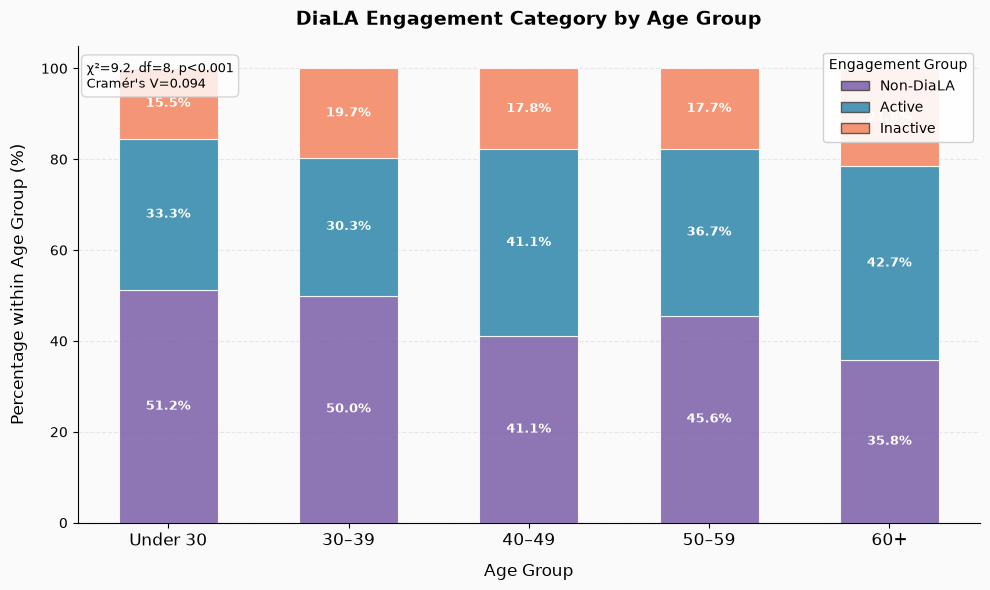


Plot saved as step4b_age_engagement.png


In [11]:
# Age x Engagement Level - Here, I'm looking at how age groups vary across engagement levels. This includes descriptive statistics, chi-squared test, Cramér's V effect size, and a stacked bar chart visualization.
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
# Assumes final_df already exists 
 
group_labels = {0: "Non-DiaLA", 1: "Active", 2: "Inactive"}
age_labels   = {0: "Under 30", 1: "30–39", 2: "40–49", 3: "50–59", 4: "60+"}
colors       = ["#7B5EA7", "#2E86AB", "#F4845F"]   # purple, blue, orange
 
# CROSSTAB
 
ct = pd.crosstab(
    final_df["New_Age"].map(age_labels),
    final_df["Category_New"].map(group_labels)
)
ct = ct[["Non-DiaLA", "Active", "Inactive"]]
ct.index = pd.CategoricalIndex(ct.index,
           categories=["Under 30", "30–39", "40–49", "50–59", "60+"], ordered=True)
ct = ct.sort_index()
 
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
 
# DESCRIPTIVE Stats
 
print("=" * 70)
print("STEP 4B: AGE GROUP BY ENGAGEMENT CATEGORY — DESCRIPTIVES")
print("=" * 70)
 
print(f"\n{'Age Group':<12} {'Non-DiaLA':>18} {'Active':>18} {'Inactive':>18}  {'Total':>8}")
print("-" * 78)
for age in ["Under 30", "30–39", "40–49", "50–59", "60+"]:
    row_total = ct.loc[age].sum()
    nd  = f"{ct.loc[age,'Non-DiaLA']:,} ({ct_pct.loc[age,'Non-DiaLA']:.1f}%)"
    act = f"{ct.loc[age,'Active']:,} ({ct_pct.loc[age,'Active']:.1f}%)"
    ina = f"{ct.loc[age,'Inactive']:,} ({ct_pct.loc[age,'Inactive']:.1f}%)"
    print(f"  {age:<10} {nd:>18} {act:>18} {ina:>18}  {row_total:>8,}")
 
col_totals = ct.sum(axis=0)
print("-" * 78)
print(f"  {'Total':<10} {col_totals['Non-DiaLA']:>10,}      "
      f"{col_totals['Active']:>10,}      {col_totals['Inactive']:>10,}"
      f"  {ct.values.sum():>8,}")
print("\n  Cell values: N (row %)")
 
# CHI-SQUARED + CRAMÉR'S V
 
print("\n" + "=" * 70)
print("INFERENTIAL STATISTICS")
print("=" * 70)
 
chi2, p, dof, _ = chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
 
print(f"\nChi-squared = {chi2:.3f},  df = {dof},  p = {p:.4f}")
print(f"Cramér's V  = {cramers_v:.3f}  (effect size: <0.1 negligible, 0.1–0.3 small, >0.3 moderate)")
 
# STACKED BAR CHART
 
age_order = ["Under 30", "30–39", "40–49", "50–59", "60+"]
pct_vals  = ct_pct.loc[age_order]
 
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")
 
x          = np.arange(len(age_order))
bar_width  = 0.55
bottom     = np.zeros(len(age_order))
 
for col, color in zip(["Non-DiaLA", "Active", "Inactive"], colors):
    vals = pct_vals[col].values
    ax.bar(x, vals, bar_width, bottom=bottom,
           color=color, alpha=0.85, edgecolor="white", linewidth=0.8)
    for i, (v, bot) in enumerate(zip(vals, bottom)):
        if v >= 6:
            ax.text(x[i], bot + v / 2, f"{v:.1f}%",
                    ha="center", va="center", fontsize=9,
                    fontweight="bold", color="white")
    bottom += vals
 
ax.set_xticks(x)
ax.set_xticklabels(age_order, fontsize=12)
ax.set_ylabel("Percentage within Age Group (%)", fontsize=12, labelpad=10)
ax.set_xlabel("Age Group", fontsize=12, labelpad=10)
ax.set_title("DiaLA Engagement Category by Age Group", fontsize=14,
             fontweight="bold", pad=15)
ax.set_ylim(0, 105)
ax.yaxis.grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
 
patches = [mpatches.Patch(facecolor=c, alpha=0.85, label=l, edgecolor="#444444")
           for c, l in zip(colors, ["Non-DiaLA", "Active", "Inactive"])]
ax.legend(handles=patches, fontsize=10, loc="upper right",
          framealpha=0.9, edgecolor="#CCCCCC", title="Engagement Group",
          title_fontsize=10)
 
ax.text(0.01, 0.97, f"χ²={chi2:.1f}, df={dof}, p<0.001\nCramér's V={cramers_v:.3f}",
        transform=ax.transAxes, fontsize=9, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#CCCCCC", alpha=0.8))
 
plt.tight_layout()
plt.savefig("step4b_age_engagement.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nPlot saved as step4b_age_engagement.png")


STEP 4C: GENDER BY ENGAGEMENT CATEGORY — DESCRIPTIVES

Gender              Non-DiaLA             Active           Inactive     Total
----------------------------------------------------------------------------
  Male            115 (41.2%)        108 (38.7%)         56 (20.1%)       279
  Female          105 (43.6%)         92 (38.2%)         44 (18.3%)       241
----------------------------------------------------------------------------
  Total           220             200             100       520

  Cell values: N (row %)

INFERENTIAL STATISTICS

Chi-squared = 0.400,  df = 2,  p = 0.8188
Cramér's V  = 0.028  (effect size: <0.1 negligible, 0.1–0.3 small, >0.3 moderate)


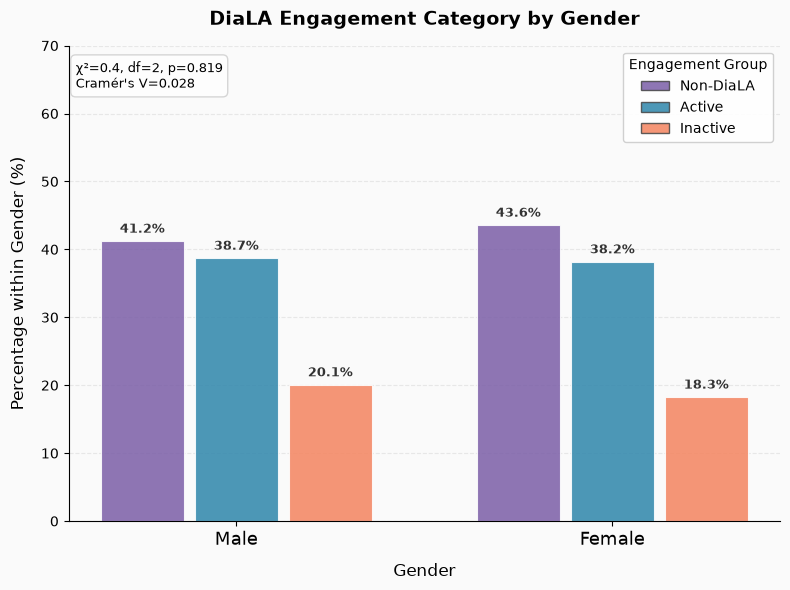


Plot saved as step4c_gender_engagement.png

WITHIN-GENDER ANALYSIS

── 1. Goodness-of-Fit Chi-squared (within each gender) ──────────
   H0: engagement categories are equally distributed within gender
----------------------------------------------------------------------

  Male (N=279)
    Observed:  Non-DiaLA=115 (41.2%)  Active=108 (38.7%)  Inactive=56 (20.1%)
    Chi-squared = 22.344,  df = 2,  p = 0.0000  ***
    → Proportions are NOT equally distributed

  Female (N=241)
    Observed:  Non-DiaLA=105 (43.6%)  Active=92 (38.2%)  Inactive=44 (18.3%)
    Chi-squared = 25.701,  df = 2,  p = 0.0000  ***
    → Proportions are NOT equally distributed

── 2. Two-Proportion Z-test: Non-DiaLA vs Active within Females ──
   H0: proportion Non-DiaLA = proportion Active among females
----------------------------------------------------------------------

  Female Non-DiaLA: 43.57%
  Female Active:    38.17%
  Difference:       5.39 percentage points
  Z = 1.2045,  p = 0.2284  ns
  → The diffe

In [12]:

# Gender X Engagememt Level - I then wanted to look at how gender varies across engagement levels. This includes descriptive
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
# Assumes final_df already exists 
 
group_labels  = {0: "Non-DiaLA", 1: "Active", 2: "Inactive"}
gender_labels = {1: "Male", 2: "Female"}
colors        = ["#7B5EA7", "#2E86AB", "#F4845F"]   # purple, blue, orange

# CROSSTAB
 
ct = pd.crosstab(
    final_df["New_Gender"].map(gender_labels),
    final_df["Category_New"].map(group_labels)
)
ct = ct[["Non-DiaLA", "Active", "Inactive"]]
ct = ct.loc[["Male", "Female"]]
 
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
 
# DESCRIPTIVES STATS
 
print("=" * 70)
print("STEP 4C: GENDER BY ENGAGEMENT CATEGORY — DESCRIPTIVES")
print("=" * 70)
 
print(f"\n{'Gender':<10} {'Non-DiaLA':>18} {'Active':>18} {'Inactive':>18}  {'Total':>8}")
print("-" * 76)
for gender in ["Male", "Female"]:
    row_total = ct.loc[gender].sum()
    nd  = f"{ct.loc[gender,'Non-DiaLA']:,} ({ct_pct.loc[gender,'Non-DiaLA']:.1f}%)"
    act = f"{ct.loc[gender,'Active']:,} ({ct_pct.loc[gender,'Active']:.1f}%)"
    ina = f"{ct.loc[gender,'Inactive']:,} ({ct_pct.loc[gender,'Inactive']:.1f}%)"
    print(f"  {gender:<8} {nd:>18} {act:>18} {ina:>18}  {row_total:>8,}")
 
col_totals = ct.sum(axis=0)
print("-" * 76)
print(f"  {'Total':<8} {col_totals['Non-DiaLA']:>10,}      "
      f"{col_totals['Active']:>10,}      {col_totals['Inactive']:>10,}"
      f"  {ct.values.sum():>8,}")
print("\n  Cell values: N (row %)")
 
# CHI-SQUARED + CRAMÉR'S V
 
print("\n" + "=" * 70)
print("INFERENTIAL STATISTICS")
print("=" * 70)
 
chi2, p, dof, _ = chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
 
print(f"\nChi-squared = {chi2:.3f},  df = {dof},  p = {p:.4f}")
print(f"Cramér's V  = {cramers_v:.3f}  (effect size: <0.1 negligible, 0.1–0.3 small, >0.3 moderate)")
 
# GROUPED BAR CHART
 
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")
 
x         = np.arange(2)           # Male, Female
bar_width = 0.25
offsets   = [-bar_width, 0, bar_width]
groups    = ["Non-DiaLA", "Active", "Inactive"]
 
for offset, col, color in zip(offsets, groups, colors):
    vals = [ct_pct.loc[g, col] for g in ["Male", "Female"]]
    bars = ax.bar(x + offset, vals, bar_width - 0.03,
                  color=color, alpha=0.85, edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f"{v:.1f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color="#333333")
 
ax.set_xticks(x)
ax.set_xticklabels(["Male", "Female"], fontsize=13)
ax.set_ylabel("Percentage within Gender (%)", fontsize=12, labelpad=10)
ax.set_xlabel("Gender", fontsize=12, labelpad=10)
ax.set_title("DiaLA Engagement Category by Gender", fontsize=14,
             fontweight="bold", pad=15)
ax.set_ylim(0, 70)
ax.yaxis.grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
 
patches = [mpatches.Patch(facecolor=c, alpha=0.85, label=l, edgecolor="#444444")
           for c, l in zip(colors, groups)]
ax.legend(handles=patches, fontsize=10, loc="upper right",
          framealpha=0.9, edgecolor="#CCCCCC", title="Engagement Group",
          title_fontsize=10)
 
ax.text(0.01, 0.97, f"χ²={chi2:.1f}, df={dof}, p={'<0.001' if p < 0.001 else f'{p:.3f}'}\nCramér's V={cramers_v:.3f}",
        transform=ax.transAxes, fontsize=9, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#CCCCCC", alpha=0.8))
 
plt.tight_layout()
plt.savefig("step4c_gender_engagement.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nPlot saved as step4c_gender_engagement.png")
 
# WITHIN-GENDER ANALYSIS
 
from scipy import stats as stats_module
 
print("\n" + "=" * 70)
print("WITHIN-GENDER ANALYSIS")
print("=" * 70)
 
# 1. Goodness-of-fit chi-squared within each gender 
print("\n── 1. Goodness-of-Fit Chi-squared (within each gender) ──────────")
print("   H0: engagement categories are equally distributed within gender")
print("-" * 70)
 
for gender in ["Male", "Female"]:
    observed = ct.loc[gender].values
    total    = observed.sum()
    expected = np.array([total / 3] * 3)
    chi2_gof, p_gof = stats_module.chisquare(observed, f_exp=expected)
    sig = "***" if p_gof < 0.001 else "**" if p_gof < 0.01 else "*" if p_gof < 0.05 else "ns"
    print(f"\n  {gender} (N={total:,})")
    print(f"    Observed:  Non-DiaLA={observed[0]:,} ({observed[0]/total*100:.1f}%)  "
          f"Active={observed[1]:,} ({observed[1]/total*100:.1f}%)  "
          f"Inactive={observed[2]:,} ({observed[2]/total*100:.1f}%)")
    print(f"    Chi-squared = {chi2_gof:.3f},  df = 2,  p = {p_gof:.4f}  {sig}")
    print(f"    → Proportions are {'equally' if p_gof > 0.05 else 'NOT equally'} distributed")
 
# 2. Two-proportion z-test: Non-DiaLA vs Active within females 
print("\n── 2. Two-Proportion Z-test: Non-DiaLA vs Active within Females ──")
print("   H0: proportion Non-DiaLA = proportion Active among females")
print("-" * 70)
 
female_total   = ct.loc["Female"].sum()
female_nondila = ct.loc["Female", "Non-DiaLA"]
female_active  = ct.loc["Female", "Active"]
 
p1     = female_nondila / female_total
p2     = female_active  / female_total
p_pool = (female_nondila + female_active) / (2 * female_total)
se     = np.sqrt(p_pool * (1 - p_pool) * (2 / female_total))
z      = (p1 - p2) / se
p_z    = 2 * (1 - stats_module.norm.cdf(abs(z)))
sig_f  = "***" if p_z < 0.001 else "**" if p_z < 0.01 else "*" if p_z < 0.05 else "ns"
 
print(f"\n  Female Non-DiaLA: {p1*100:.2f}%")
print(f"  Female Active:    {p2*100:.2f}%")
print(f"  Difference:       {abs(p1-p2)*100:.2f} percentage points")
print(f"  Z = {z:.4f},  p = {p_z:.4f}  {sig_f}")
print(f"  → The difference is {'NOT ' if p_z > 0.05 else ''}statistically significant")
 
# 3. Two-proportion z-test: Non-DiaLA vs Active within males 
print("\n── 3. Two-Proportion Z-test: Non-DiaLA vs Active within Males ────")
print("   (reference comparison)")
print("-" * 70)
 
male_total   = ct.loc["Male"].sum()
male_nondila = ct.loc["Male", "Non-DiaLA"]
male_active  = ct.loc["Male", "Active"]
 
p1m      = male_nondila / male_total
p2m      = male_active  / male_total
p_pool_m = (male_nondila + male_active) / (2 * male_total)
se_m     = np.sqrt(p_pool_m * (1 - p_pool_m) * (2 / male_total))
z_m      = (p1m - p2m) / se_m
p_zm     = 2 * (1 - stats_module.norm.cdf(abs(z_m)))
sig_m    = "***" if p_zm < 0.001 else "**" if p_zm < 0.01 else "*" if p_zm < 0.05 else "ns"
 
print(f"\n  Male Non-DiaLA: {p1m*100:.2f}%")
print(f"  Male Active:    {p2m*100:.2f}%")
print(f"  Difference:     {abs(p1m-p2m)*100:.2f} percentage points")
print(f"  Z = {z_m:.4f},  p = {p_zm:.4f}  {sig_m}")
print(f"  → The difference is {'NOT ' if p_zm > 0.05 else ''}statistically significant")
 
# Summary 
print(f"\n{'='*70}")
print("SUMMARY")
print(f"{'='*70}")
print(f"  Males:   Active ({p2m*100:.1f}%) >> Non-DiaLA ({p1m*100:.1f}%)  "
      f"[{abs(p1m-p2m)*100:.1f}pp gap, {sig_m}]")
print(f"  Females: Active ({p2*100:.1f}%) ≈  Non-DiaLA ({p1*100:.1f}%)  "
      f"[{abs(p1-p2)*100:.1f}pp gap, {sig_f}]")
print(f"  → Active engagement dominates among males but not females")

Fitting Model 1 (ref = Non-DiaLA)...
Fitting Model 2 (ref = Active)...
Done.

STEP 4D: MULTINOMIAL LOGISTIC REGRESSION
  Predictors: Occupation score + Age group + Gender
  N = 520

  ── Active vs Non-DiaLA ─────────────────────────────
  Variable                             OR            95% CI         p      
  -------------------------------- ------  ----------------  --------  ----
  Intercept                         0.793  (0.361–1.743)    0.5646  ns
  Occupation score (Kuppuswamy)     0.980  (0.916–1.048)    0.5481  ns
  Age group (0=<30 … 4=60+)         1.170  (1.030–1.329)    0.0160  *
  Gender (ref=Male, 2=Female)       0.923  (0.626–1.361)    0.6856  ns

  ── Inactive vs Active ──────────────────────────────
  Variable                             OR            95% CI         p      
  -------------------------------- ------  ----------------  --------  ----
  Intercept                         0.304  (0.107–0.864)    0.0254  *
  Occupation score (Kuppuswamy)     1.099  (1.003–

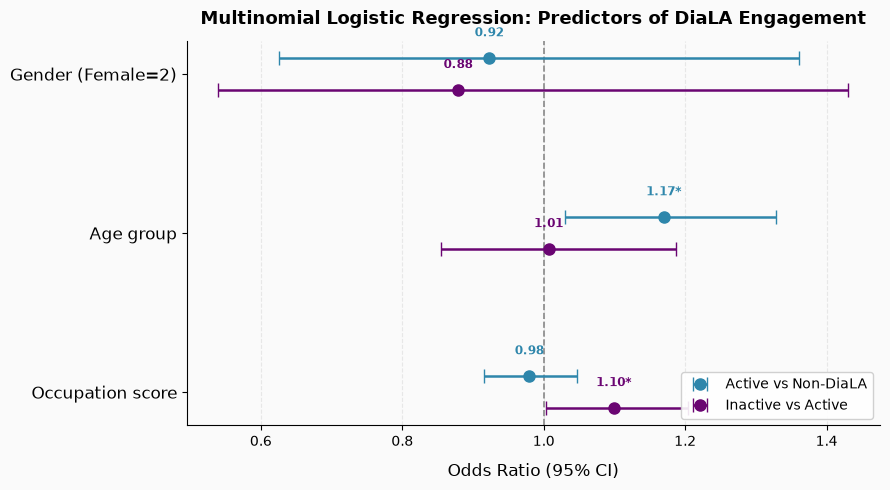


Forest plot saved as step4d_regression_forest.png


In [13]:
# Multinomial Regression x Engagement Level (Controls) - If we control for other variables, basically how does the analsis turn out?
import pandas as pd
import numpy as np
from statsmodels.formula.api import mnlogit
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# Assumes final_df already exists 

reg_df = final_df[["Category_New", "Kupp_Occupation", "New_Age", "New_Gender"]].dropna().copy()
reg_df["Category_New"] = reg_df["Category_New"].astype(int)

# MODEL 1: ref = Non-DiaLA  →  gives Active vs Non-DiaLA

print("Fitting Model 1 (ref = Non-DiaLA)...")
model1 = mnlogit(
    "Category_New ~ Kupp_Occupation + New_Age + New_Gender",
    data=reg_df
).fit(method="newton", maxiter=1000, disp=False)

params1  = model1.params
pvalues1 = model1.pvalues
ci1      = model1.conf_int()
n_vars1  = len(params1)

# MODEL 2: ref = Active  →  gives Inactive vs Active
# Recode: Active=0 (ref), Non-DiaLA=1, Inactive=2
# We only need the Inactive vs Active equation (eq_idx=1)

print("Fitting Model 2 (ref = Active)...")
reg_df2 = reg_df.copy()
recode  = {0: 1, 1: 0, 2: 2}   # Non-DiaLA→1, Active→0(ref), Inactive→2
reg_df2["Category_New"] = reg_df2["Category_New"].map(recode)

model2 = mnlogit(
    "Category_New ~ Kupp_Occupation + New_Age + New_Gender",
    data=reg_df2
).fit(method="newton", maxiter=1000, disp=False)

params2  = model2.params
pvalues2 = model2.pvalues
ci2      = model2.conf_int()
n_vars2  = len(params2)

print("Done.\n")

var_labels = {
    "Intercept":       "Intercept",
    "Kupp_Occupation": "Occupation score (Kuppuswamy)",
    "New_Age":         "Age group (0=<30 … 4=60+)",
    "New_Gender":      "Gender (ref=Male, 2=Female)",
}
# OR TABLE

print("=" * 75)
print("STEP 4D: MULTINOMIAL LOGISTIC REGRESSION")
print("  Predictors: Occupation score + Age group + Gender")
print(f"  N = {len(reg_df):,}")
print("=" * 75)

def print_eq(params, pvalues, ci_all, eq_idx, outcome_label, var_labels):
    n_vars = len(params)
    ci_eq  = ci_all.iloc[eq_idx * n_vars : (eq_idx + 1) * n_vars]
    print(f"\n  ── {outcome_label} {'─' * (48 - len(outcome_label))}")
    print(f"  {'Variable':<32} {'OR':>6}  {'95% CI':>16}  {'p':>8}  {'':>4}")
    print(f"  {'-'*32} {'-'*6}  {'-'*16}  {'-'*8}  {'-'*4}")
    for i, var in enumerate(params.index):
        coef  = params.iloc[i, eq_idx]
        lo    = ci_eq.iloc[i]["lower"]
        hi    = ci_eq.iloc[i]["upper"]
        p     = pvalues.iloc[i, eq_idx]
        OR    = np.exp(coef)
        OR_lo = np.exp(lo)
        OR_hi = np.exp(hi)
        sig   = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        label = var_labels.get(var, var)
        print(f"  {label:<32} {OR:>6.3f}  ({OR_lo:.3f}–{OR_hi:.3f})  {p:>8.4f}  {sig}")

# Active vs Non-DiaLA: model1, eq_idx=0
print_eq(params1, pvalues1, ci1, 0, "Active vs Non-DiaLA", var_labels)

# Inactive vs Active: model2, eq_idx=1  (Inactive is category 2, Active is ref=0)
print_eq(params2, pvalues2, ci2, 1, "Inactive vs Active", var_labels)

print(f"\n  *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")
print(f"  OR > 1 = higher odds of first-named group vs reference")

# FOREST PLOT

plot_vars   = ["Kupp_Occupation", "New_Age", "New_Gender"]
plot_labels = ["Occupation score", "Age group", "Gender (Female=2)"]

comparisons = [
    ("Active vs Non-DiaLA", params1, pvalues1, ci1,  0, "#2E86AB"),
    ("Inactive vs Active",  params2, pvalues2, ci2,  1, "#6A0572"),
]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

y_positions = np.arange(len(plot_vars))
offset      = 0.2

for plot_i, (outcome_label, params, pvalues, ci_all, eq_idx, color) in enumerate(comparisons):
    n_vars = len(params)
    ci_eq  = ci_all.iloc[eq_idx * n_vars : (eq_idx + 1) * n_vars]
    ci_eq  = ci_eq.set_index(params.index)

    ors = [np.exp(params.iloc[list(params.index).index(v), eq_idx]) for v in plot_vars]
    los = [np.exp(ci_eq.loc[v, "lower"]) for v in plot_vars]
    his = [np.exp(ci_eq.loc[v, "upper"]) for v in plot_vars]
    ps  = [pvalues.iloc[list(params.index).index(v), eq_idx] for v in plot_vars]

    y = y_positions + (0.5 - plot_i) * offset

    ax.errorbar(
        ors, y,
        xerr=[np.array(ors) - np.array(los), np.array(his) - np.array(ors)],
        fmt="o", color=color, markersize=8, capsize=5,
        linewidth=1.8, label=outcome_label, zorder=3
    )

    for or_val, yi, p in zip(ors, y, ps):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        ax.text(or_val, yi + 0.12, f"{or_val:.2f}{sig}",
                fontsize=8.5, va="bottom", ha="center",
                color=color, fontweight="bold")

ax.axvline(x=1, color="#888888", linestyle="--", linewidth=1.2, zorder=1)
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_labels, fontsize=12)
ax.set_xlabel("Odds Ratio (95% CI)", fontsize=12, labelpad=10)
ax.set_title("Multinomial Logistic Regression: Predictors of DiaLA Engagement",
             fontsize=13, fontweight="bold", pad=12)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=10, loc="lower right", framealpha=0.9, edgecolor="#CCCCCC")

plt.tight_layout()
plt.savefig("step4d_regression_forest.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nForest plot saved as step4d_regression_forest.png")